# 06 - Seleção de Variáveis Avançada (ExtraTrees Importance)

**Objetivo:** Consolidar todas as features geradas (Temporais, Contextuais, Clima, Cardápio e BERT) e reduzir a dimensionalidade para os 50 preditores mais impactantes.

**Por que Selecionar?** 
- **Evitar Overfitting:** Reduzir o ruído de colunas irrelevantes.
- **Eficiência:** Modelos mais rápidos e interpretáveis.
- **Qualidade:** Focar no que realmente move o comportamento do consumo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesRegressor
import os
import warnings
warnings.filterwarnings("ignore")

# Configurações
BASE_FEATURES = '../data/base_features_final.csv'
BASE_BERT = '../data/embeddings_bert_cardapio.csv'
SAIDA_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

## 1. Unificação das Bases (Multidimensional)
Cruzando os 36 preditores do Notebook 04 com os 768 embeddings do Notebook 05.

In [2]:
# Carregamento
df_feat = pd.read_csv(BASE_FEATURES)
df_bert = pd.read_csv(BASE_BERT)

df_feat['data'] = pd.to_datetime(df_feat['data'])
df_bert['data'] = pd.to_datetime(df_bert['data'])

# Merge Final
df = pd.merge(df_feat, df_bert, on='data', how='inner')
df = df.sort_values('data').reset_index(drop=True)

print(f"📦 Base Unificada: {df.shape[0]} registros e {df.shape[1]} colunas.")

📦 Base Unificada: 191 registros e 803 colunas.


## 2. Preparação para Seleção
Limpando colunas não-numéricas e garantindo que o alvo não vaze.

In [3]:
# Colunas de metadados ou que causam leakage
DROP_COLS = ['data', 'total_servido', 'id_aluno_anonimo', 'nome_aluno', 'turma', 'refeicao']
# Outros componentes do alvo que podem ter sobrado
DROP_COLS += ['reservou_e_comeu', 'nao_reservou_e_comeu', 'reservou_e_nao_comeu']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df[TARGET]

# Manter apenas numéricas para o ExtraTrees
X = X.select_dtypes(include=[np.number])

print(f"🔍 Matriz de Previsão X: {X.shape[1]} variáveis prontas.")

🔍 Matriz de Previsão X: 800 variáveis prontas.


## 3. Seleção de Relevância (ExtraTrees)
Calculando o ganho de informação para cada variável.

🔄 Calculando importâncias...


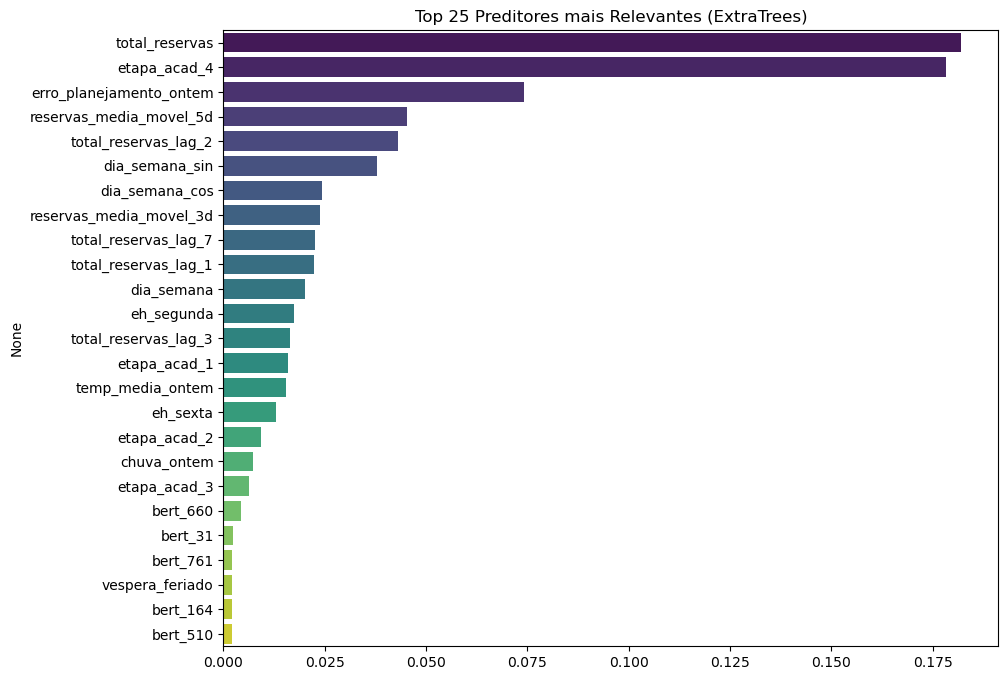

In [4]:
print("🔄 Calculando importâncias...")
et_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
et_model.fit(X, y)

# Ranking
importances = pd.Series(et_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualizar Top 25
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(25).values, y=importances.head(25).index, palette='viridis')
plt.title("Top 25 Preditores mais Relevantes (ExtraTrees)")
plt.show()

## 4. Exportação do Dataset de Alta Performance
Salvando as 50 melhores variáveis + metadados essenciais.

In [5]:
# Selecionar as 50 melhores
TOP_N = 50
best_features = importances.head(TOP_N).index.tolist()

# Criar base final compacta
df_selecionada = df[['data', TARGET] + best_features].copy()

# Salvar
df_selecionada.to_csv(SAIDA_SELECIONADA, index=False)

print(f"✨ Seleção concluída com sucesso!")
print(f"📊 Dataset salvo em: {SAIDA_SELECIONADA}")
print(f"📈 Shape final: {df_selecionada.shape}")
print(f"✅ Features mantidas: {best_features[:10]} ...")

✨ Seleção concluída com sucesso!
📊 Dataset salvo em: ../data/base_features_selecionadas.csv
📈 Shape final: (191, 52)
✅ Features mantidas: ['total_reservas', 'etapa_acad_4', 'erro_planejamento_ontem', 'reservas_media_movel_5d', 'total_reservas_lag_2', 'dia_semana_sin', 'dia_semana_cos', 'reservas_media_movel_3d', 'total_reservas_lag_7', 'total_reservas_lag_1'] ...


## 5. Interpretabilidade: O que o BERT está vendo?
Para entender o que as variáveis `bert_x` significam, vamos reduzir as 768 dimensões para apenas 2 usando **PCA**.
Isso nos permite visualizar o "mapa semântico" dos cardápios e ver se pratos parecidos estão realmente próximos no espaço matemático.

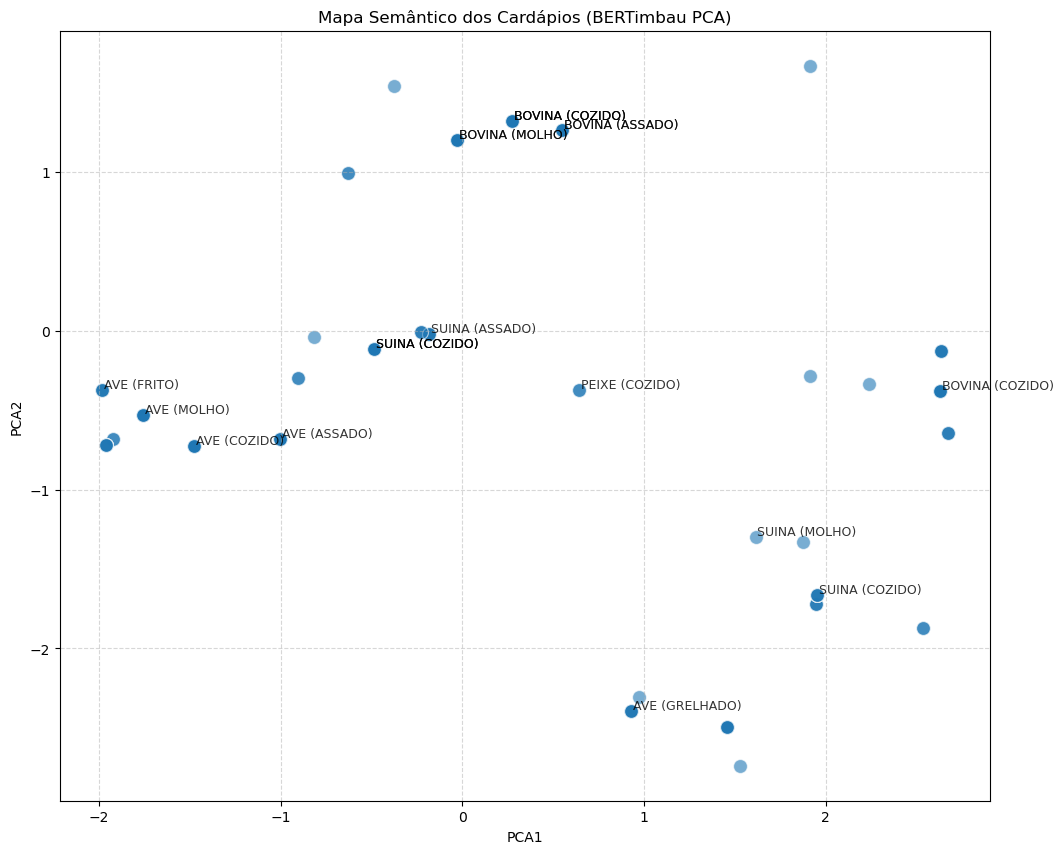

💡 Interpretação: Pratos próximos no gráfico possuem contextos semânticos similares para a IA.


In [6]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Carregar textos originais para legenda
df_card = pd.read_csv('../data/cardapio_consolidado.csv')
df_card['data'] = pd.to_datetime(df_card['data'])

# 2. Isolar apenas as colunas BERT da base unificada
bert_cols = [c for c in df.columns if c.startswith('bert_')]
X_bert = df[bert_cols]

# 3. Aplicar PCA (Redução para 2D)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_bert)

# 4. Preparar DataFrame de Visualização
df_viz = pd.DataFrame(coords, columns=['PCA1', 'PCA2'])
df_viz['data'] = df['data'].values
df_viz = pd.merge(df_viz, df_card[['data', 'proteina_principal', 'preparo_principal']], on='data', how='left')
df_viz['prato'] = df_viz['proteina_principal'].fillna('') + " (" + df_viz['preparo_principal'].fillna('') + ")"

# 5. Plotar
plt.figure(figsize=(12, 10))
scatter = sns.scatterplot(data=df_viz, x='PCA1', y='PCA2', alpha=0.6, s=100)

# Adicionar algumas anotações aleatórias para contextulizar
for i in range(0, len(df_viz), 10): # Anota a cada 10 registros para não poluir
    plt.text(df_viz.PCA1[i]+0.01, df_viz.PCA2[i]+0.01, df_viz.prato[i], fontsize=9, alpha=0.8)

plt.title("Mapa Semântico dos Cardápios (BERTimbau PCA)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("💡 Interpretação: Pratos próximos no gráfico possuem contextos semânticos similares para a IA.")